<a href="https://colab.research.google.com/github/hitomitsu50/Sports_data_portfolio_MLB_Statcast/blob/main/2025%E5%B9%B4Statcast%E8%8F%85%E9%87%8E%E6%8A%95%E6%89%8B_%E6%8A%95%E7%90%83%E5%89%B2%E5%90%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#ライブラリのインストール
!pip install pybaseball japanize_matplotlib
!sudo apt-get -y update
!sudo apt-get -y install fonts-ipaexfont

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 29.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.7/432.7 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.7 MB/s eta 0:00:00
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=5b1cedf5f1bef4f32080cb955d2fa466ce51e9c536dc2bc7d4d2ed059c719015
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubu

In [2]:
#ライブラリーのインポート
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib
import time
import glob
from pybaseball import statcast

In [3]:
#データの読み込みと結合
#ファイル名パターンに一致するＣＳＶを取得
csv_files_pattern="sample_data/statcast_*.csv"
csv_files=glob.glob(csv_files_pattern)

In [4]:
#各ＣＳＶファイルを読み込みリストに格納
dfs=[]
for file in csv_files:
  try:
    df_month=pd.read_csv(file)
    dfs.append(df_month)
    print(f"{file}を読み込みました。")
  except Exception as e:
    print(F"{file}を読み込めません:{e}")

sample_data/statcast_2025-05-01-2025-05-31.csvを読み込みました。
sample_data/statcast_2025-09-01-2025-09-28.csvを読み込みました。
sample_data/statcast_2025-04-01-2025-04-30.csvを読み込みました。
sample_data/statcast_2025-06-01-2025-06-30.csvを読み込みました。
sample_data/statcast_2025-08-01-2025-08-31.csvを読み込みました。
sample_data/statcast_2025-03-18-2025-03-31.csvを読み込みました。
sample_data/statcast_2025-07-01-2025-07-31.csvを読み込みました。


In [5]:
#全てのデータを結合
if dfs:
  df_combined=pd.concat(dfs,ignore_index=True)
  df=df_combined
  print("全てのデータを結合")
  display(df.head())
  print(f"結合後の行数:{len(df)}")

全てのデータを結合


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,FF,2025-05-31,95.7,-1.82,5.28,"Montero, Rafael",691785,606160,field_out,hit_into_play,...,1.0,1.32,0.83,-0.83,36.6,0.139455,-10.166076,40.209810,39.021897,28.779218
1,FS,2025-05-31,87.9,-1.66,5.06,"Montero, Rafael",691785,606160,NaN,foul,...,1.0,2.42,1.08,-1.08,39.2,13.728831,-2.543747,31.022651,49.545197,32.569171
2,FS,2025-05-31,88.6,-1.62,4.99,"Montero, Rafael",691785,606160,NaN,foul,...,1.0,2.70,1.16,-1.16,28.3,9.811060,4.873316,28.523588,45.344786,27.334223
3,SL,2025-05-31,81.7,-1.48,5.14,"Montero, Rafael",665966,606160,field_out,hit_into_play,...,2.0,3.38,-0.65,-0.65,36.6,22.202492,-19.609687,30.555638,38.268162,49.913181
4,FF,2025-05-31,96.3,-1.50,5.32,"Montero, Rafael",665966,606160,NaN,foul,...,2.0,1.25,0.83,0.83,34.7,1.653196,18.485025,27.030027,35.922657,23.587106


結合後の行数:742080


In [6]:
#読み込まれた各ＣＳＶの行数
for file in csv_files:
  temp_df=pd.read_csv(file)
  print(f"{file}: {len(temp_df)}行")

sample_data/statcast_2025-05-01-2025-05-31.csv: 120218行
sample_data/statcast_2025-09-01-2025-09-28.csv: 110338行
sample_data/statcast_2025-04-01-2025-04-30.csv: 114767行
sample_data/statcast_2025-06-01-2025-06-30.csv: 115816行
sample_data/statcast_2025-08-01-2025-08-31.csv: 124298行
sample_data/statcast_2025-03-18-2025-03-31.csv: 49338行
sample_data/statcast_2025-07-01-2025-07-31.csv: 107305行


In [7]:
# ---1. データ抽出と基本集計 ---
target_name_display="Tomoyuki Sugano"
df_target=df[df["player_name"].str.contains("Sugano, Tomoyuki")].copy()

# 球種ごとのカウント、平均球速、平均回転数
pitch_stats=df_target.groupby("pitch_type").agg({
    "pitch_type":"count",
    "release_speed":"mean",
    "release_spin_rate":"mean"
}).rename(columns={"pitch_type":"count"}).sort_values("count",ascending=False)

In [8]:
# --- 2. Whiff% と PutAway%の計算 ---
# Whiff% = 空振り/スイング
swings=df_target[df_target["description"].isin(["swinging_strike","foul","foul_tip",
                                                "hit_into_play","swing_strike_blocked"])]
whiffs=df_target[df_target["description"].isin(["swinging_strike","swinging_strike_blocked"])]

#PutAway% = 2ストライクからの三振/2ストライクの投球数
two_strikes=df_target[df_target["strikes"]==2]
strikeouts=two_strikes[df_target["events"].isin(["strikeout","strikeout_double_play"])]

#球種ごとの計算値を結合
pitch_stats["whiff_pct"]=(whiffs.groupby("pitch_type").size()/swings.groupby("pitch_type").size()*100)
pitch_stats["putaway_pct"]=(strikeouts.groupby("pitch_type").size()/two_strikes.groupby("pitch_type").size()*100)
pitch_stats["usage_pct"]=(pitch_stats["count"]/pitch_stats["count"].sum()*100)

/tmp/ipython-input-919/886734576.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  strikeouts=two_strikes[df_target["events"].isin(["strikeout","strikeout_double_play"])]


/tmp/ipython-input-919/2952695229.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pitch_stats.index,y=pitch_stats["usage_pct"],ax=ax1,palette="Blues_d",alpha=0.7)


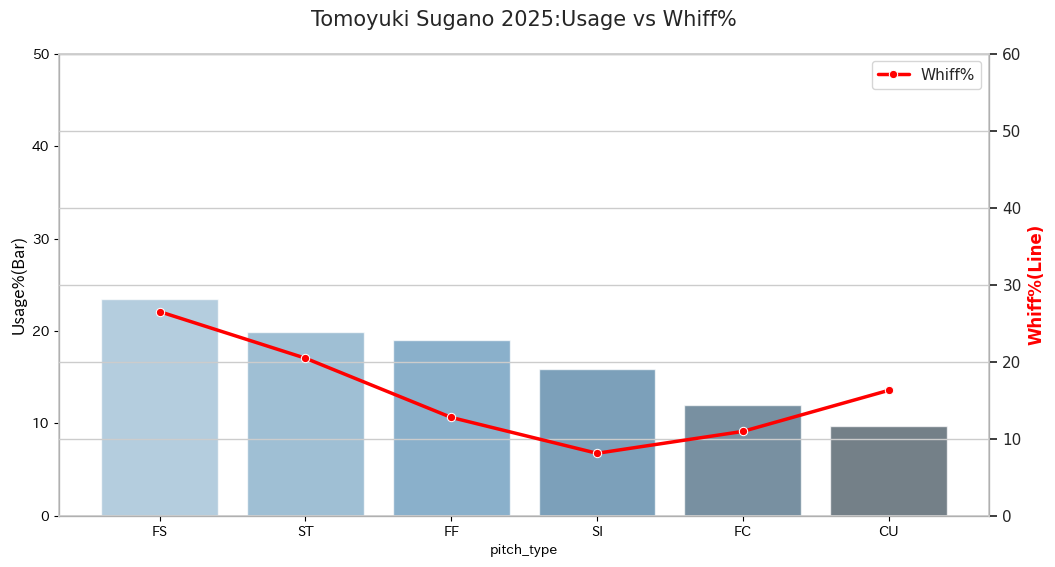

In [9]:
# --- 3. 可視化（2軸棒グラフ:割合×whiff%) ---
fig,ax1=plt.subplots(figsize=(12,6))
sns.set_theme(style="whitegrid")

# 左軸：投球割合（棒グラフ）
sns.barplot(x=pitch_stats.index,y=pitch_stats["usage_pct"],ax=ax1,palette="Blues_d",alpha=0.7)
ax1.set_ylabel("Usage%(Bar)",fontsize=12,fontweight="bold")
ax1.set_ylim(0,50)

# 右軸：Whiff%（折れ線グラフ）
ax2=ax1.twinx()
sns.lineplot(x=pitch_stats.index,y=pitch_stats["whiff_pct"],ax=ax2,color="red",marker="o",linewidth=2.5,label="Whiff%")
ax2.set_ylabel("Whiff%(Line)",color="red",fontsize=12,fontweight="bold")
ax2.set_ylim(0,60)
plt.title(f"{target_name_display} 2025:Usage vs Whiff%",fontsize=15,pad=20)
plt.show()

In [10]:
# --- 4. テキスト出力(df) ---
jp_names={"FF": "フォーシーム","FS": "スプリット","CU": "カーブ","FC": "カットボール","SI": "シンカー",
"SL": "スライダー","ST": "スイーパー"}

table_data=[]
for pitch in pitch_stats.index:
  row=pitch_stats.loc[pitch]
  table_data.append({
      "略称":pitch,
      "日本語名":jp_names.get(pitch,pitch),
      "投球数":int(row["count"]),
      "割合":f"{row["usage_pct"]:.1f}%",
      "平均球速":f"{row["release_speed"]:.1f} mph",
      "回転数":f"{int(row["release_spin_rate"])} rpm",
      "Whiff%":f"{row["whiff_pct"]:.1f}%",
      "PutAway&":f"{row["putaway_pct"]:.1f}%"
  })

In [11]:
print(f"### {target_name_display} 2025 Pitch Mix Detail")
display(pd.DataFrame(table_data))
print(f"Total Pitches: {int(pitch_stats["count"].sum())}")

### Tomoyuki Sugano 2025 Pitch Mix Detail


,略称,日本語名,投球数,割合,平均球速,回転数,Whiff%,PutAway&
0,FS,スプリット,602,23.5%,87.3 mph,1590 rpm,26.5%,21.7%
1,ST,スイーパー,509,19.8%,83.6 mph,2598 rpm,20.5%,10.1%
2,FF,フォーシーム,489,19.1%,92.7 mph,2391 rpm,12.8%,16.3%
3,SI,シンカー,408,15.9%,92.9 mph,2281 rpm,8.1%,11.5%
4,FC,カットボール,308,12.0%,88.2 mph,2471 rpm,10.9%,7.9%
5,CU,カーブ,249,9.7%,78.2 mph,2673 rpm,16.3%,4.4%


Total Pitches: 2565
